In [1]:
# from numba import cuda
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math


# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([1e3, 1e3, 1e3], dtype=float)

# m_filter = 1000*snap.mass
# filter_length = (np.cbrt(3*m_filter/(4*np.pi*snap['0_Density']))).arepo
filter_length = 2.0*snap['0_Diameters']


Attempting to get derived variable: 0_Diameters...
	So we need the variable: 0_Volume...	[DONE]



In [2]:
sf = tc.SmoothingFilter(snap, center, widths, npix=256, orientation=None, 
                        search_radius=filter_length.value)

In [3]:
sf_small = tc.SmoothingFilter(snap, center, np.array([5e2, 5e2, 5e2], dtype=float), npix=256, orientation=None, 
                        search_radius=filter_length.value)

In [4]:
sf_spherical = tc.SmoothingFilter(snap, center, widths, npix=256, orientation=None, 
                        search_radius=filter_length.value, tilingType='spherical', rMin=0.0, rMax=8e2)

In [5]:

filt_density = sf.filter_variable('0_Density',filter_length, 
                                  weight='0_Volume', filter_type="gaussian")

In [6]:

filt_density_small = sf_small.filter_variable('0_Density',filter_length, 
                                              weight='0_Volume', filter_type="gaussian")

In [7]:
filt_density_spherical = sf_spherical.filter_variable('0_Density',filter_length,
                                                      weight='0_Volume', filter_type="gaussian")

In [8]:
mask_cartesian = np.zeros(snap['0_Density'].shape,dtype='int')
mask_cartesian[sf.index] = sf.isParticleInDomainUnSorted.get()

mask_small = np.zeros(snap['0_Density'].shape,dtype='int')
mask_small[sf_small.index] = sf_small.isParticleInDomainUnSorted.get()

mask_spherical = np.zeros(snap['0_Density'].shape,dtype='int')
mask_spherical[sf_spherical.index] = sf_spherical.isParticleInDomainUnSorted.get()

In [9]:
snap['0_smooth_var_default'] = snap['0_Density'].copy
snap['0_smooth_var_default'][mask_cartesian>0] = filt_density[sf.isParticleInDomainUnSorted.get()>0]

snap['0_smooth_var_small'] = snap['0_Density'].copy
snap['0_smooth_var_small'][mask_small>0] = filt_density_small[sf_small.isParticleInDomainUnSorted.get()>0]

snap['0_smooth_var_spherical'] = snap['0_Density'].copy
snap['0_smooth_var_spherical'][mask_spherical>0] = filt_density_spherical[sf_spherical.isParticleInDomainUnSorted.get()>0]

In [10]:
mask_tot_small = mask_cartesian*mask_small
mask_tot_inter = mask_cartesian*mask_spherical


In [11]:
np.allclose(snap['0_smooth_var_default'][np.argwhere(mask_tot_small>0)].value, 
            snap['0_smooth_var_small'][np.argwhere(mask_tot_small>0)].value, 
            rtol=1e-12, atol=1e-8)

True

In [12]:
np.allclose(snap['0_smooth_var_default'][np.argwhere(mask_tot_inter>0)].value, 
            snap['0_smooth_var_spherical'][np.argwhere(mask_tot_inter>0)].value, 
            rtol=1e-12, atol=1e-8)

True

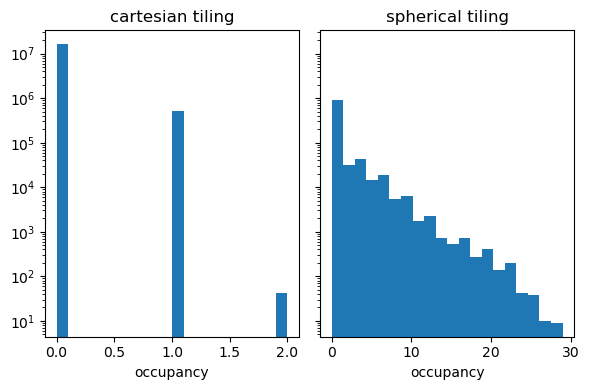

min/max occupancy cartesian tiling 0 / 2
min/max occupancy smaller tiling 0 / 29


In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

n_bins = 20

fig, axs = plt.subplots(1, 2, figsize=(6,4),sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs[0].hist(cp.asnumpy(sf.tile.particles_per_tile).flatten(), bins=n_bins)
axs[1].hist(cp.asnumpy(sf_spherical.tile.particles_per_tile).flatten(), bins=n_bins)

axs[0].set_yscale('log')
axs[1].set_yscale('log')

axs[0].set_title('cartesian tiling')
axs[1].set_title('spherical tiling')

axs[0].set_xlabel('occupancy')
axs[1].set_xlabel('occupancy')

plt.show()

print("min/max occupancy cartesian tiling %d / %d"%(sf.tile.particles_per_tile.min(),sf.tile.particles_per_tile.max()))
print("min/max occupancy smaller tiling %d / %d"%(sf_spherical.tile.particles_per_tile.min(),sf_spherical.tile.particles_per_tile.max()))

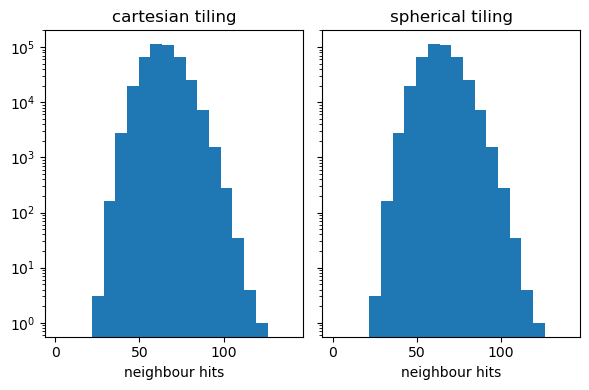

min/max hits cartesian tiling 27 / 121
min/max hits spherical tiling 27 / 121


In [16]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

# this brings back the intersection region into the respective
# cartesian/spherical selection with appropriate sorting
masktot2spherical_srt = mask_tot_inter[sf_spherical.index][sf_spherical.tile.sort_index.get()]
masktot2cartesian_srt = mask_tot_inter[sf.index][sf.tile.sort_index.get()]

hitsNeighbours_cartesian_common = cp.asnumpy(sf.hitsNeighbours)[np.argwhere(masktot2cartesian_srt>0)]
hitsNeighbours_spherical_common = cp.asnumpy(sf_spherical.hitsNeighbours)[np.argwhere(masktot2spherical_srt>0)]

n_bins = 20

fig, axs = plt.subplots(1, 2, figsize=(6,4),sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs[0].hist(hitsNeighbours_cartesian_common, bins=n_bins, range=[1,140])
axs[1].hist(hitsNeighbours_spherical_common, bins=n_bins,range=[1,140])

axs[0].set_yscale('log')
axs[1].set_yscale('log')

axs[0].set_title('cartesian tiling')
axs[1].set_title('spherical tiling')

axs[0].set_xlabel('neighbour hits')
axs[1].set_xlabel('neighbour hits')

plt.show()

print("min/max hits cartesian tiling %d / %d"%(hitsNeighbours_cartesian_common.min(),hitsNeighbours_cartesian_common.max()))
print("min/max hits spherical tiling %d / %d"%(hitsNeighbours_spherical_common.min(),hitsNeighbours_spherical_common.max()))